In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
df = pd.read_csv("/kaggle/input/datasets/madhusudhanpallela/disease/Document from Madhusudhan.csv")

print(df.head())
print(df.shape)


         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary movements  chest tightness  ... 

In [15]:
print(df.isnull().sum())

import numpy as np

# Fill numerical columns
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64


In [1]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

NameError: name 'LabelEncoder' is not defined

Dataset Loaded Successfully!
Shape: (189647, 378)

First 5 Rows:


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0



Column Names:
['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'lump in throat', 'throat feels tight', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'groin mass', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'emotional symptoms', 'elbow weakness', 'back weakness', 'pus in sputum', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'flatulence', 'pus draining from ear', 'jaundice', 'mass in scrotum', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'he

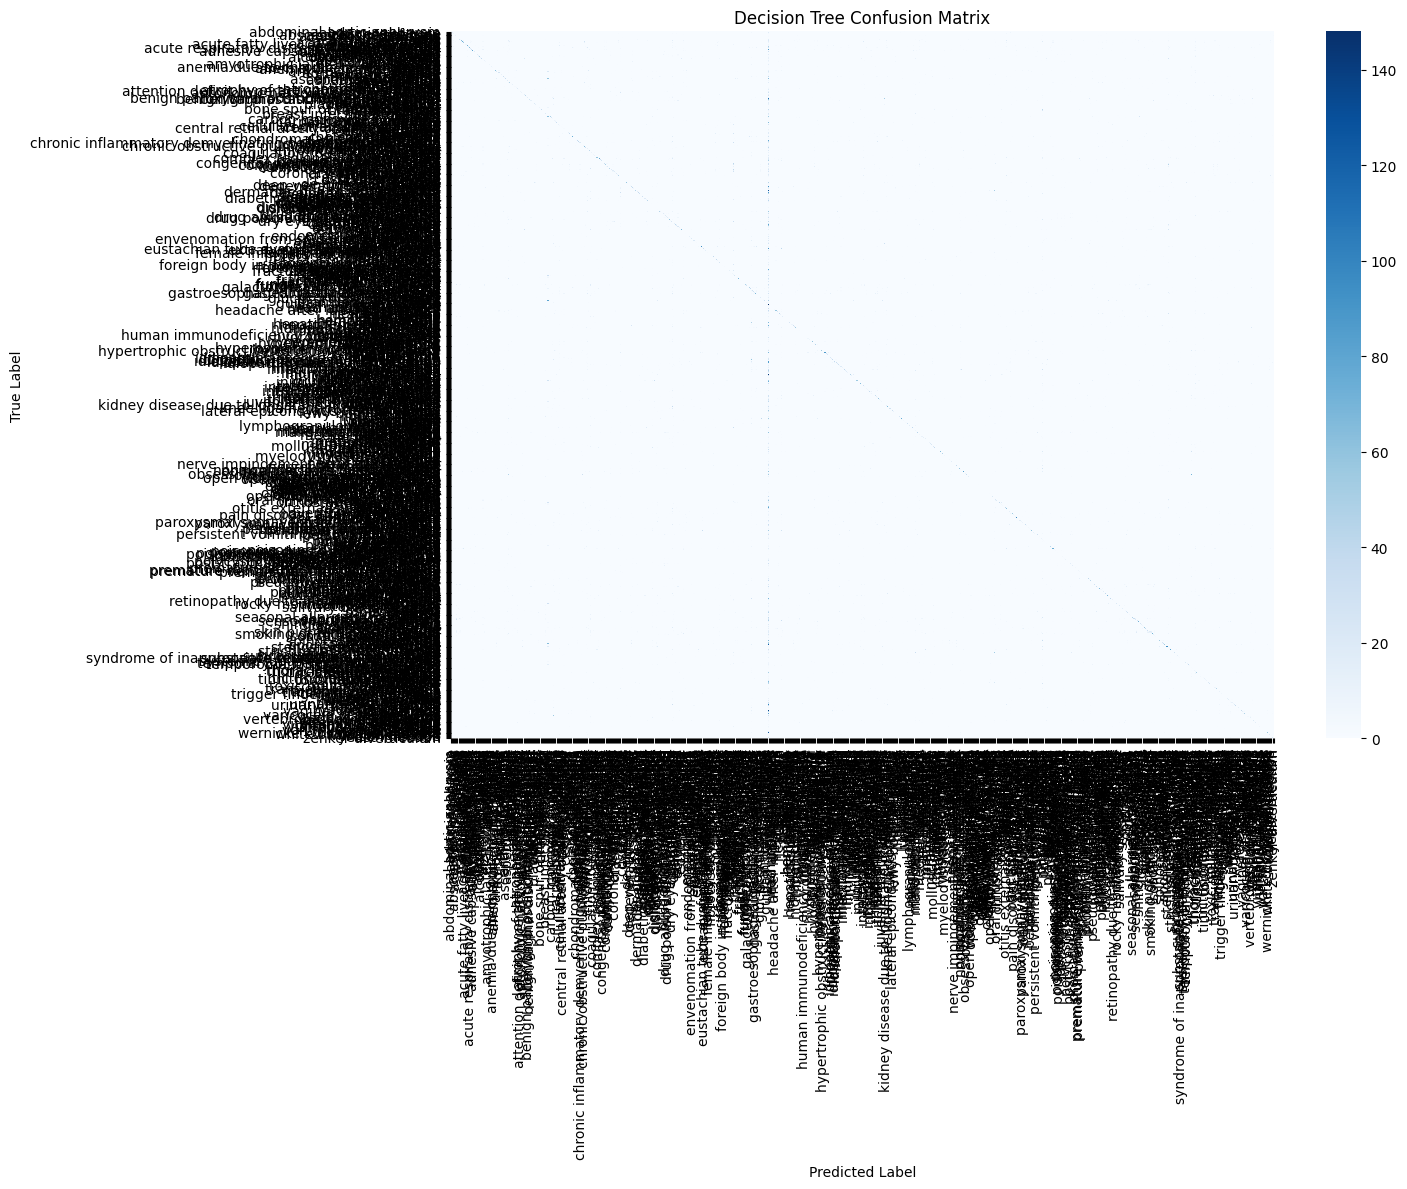


Top 30 Important Features:


,Feature,Importance
47,sharp abdominal pain,0.054734
50,headache,0.051295
5,dizziness,0.048993
4,sharp chest pain,0.048951
15,cough,0.048531
3,depressive or psychotic symptoms,0.039013
2,shortness of breath,0.038445
49,vomiting,0.036188
25,leg pain,0.032402
22,skin swelling,0.029440


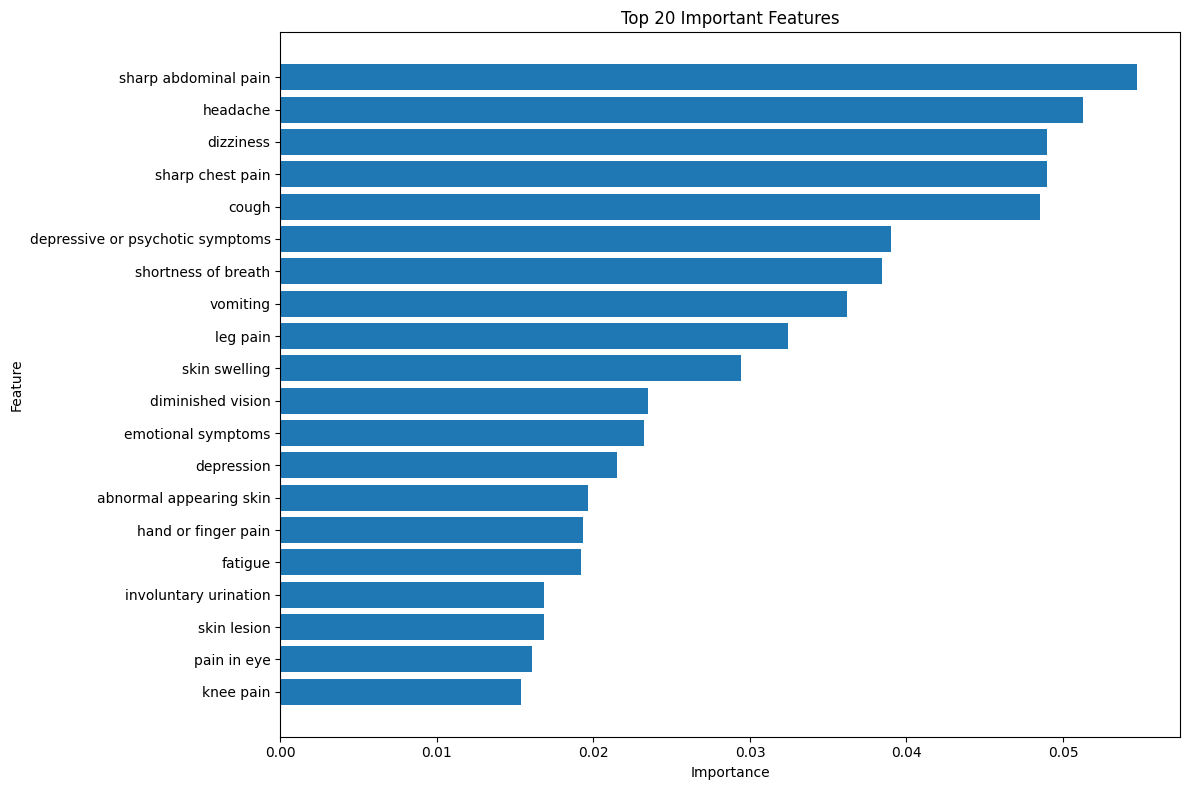


DECISION TREE INFORMATION
Tree Depth: 20
Number of Leaves: 11092
Number of Features: 377

FILES SAVED SUCCESSFULLY
/kaggle/working/decision_tree_disease_model.pkl
/kaggle/working/decision_tree_features.pkl
/kaggle/working/disease_label_encoder.pkl


In [1]:
# ============================================================
# DECISION TREE CLASSIFIER - COMPLETE KAGGLE CODE
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/madhusudhanpallela/disease/Document from Madhusudhan.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())

# ============================================================
# 4. SELECT TARGET COLUMN
# ============================================================

# CHANGE THIS ONLY IF YOUR TARGET COLUMN HAS A DIFFERENT NAME
TARGET_COLUMN = "diseases"

if TARGET_COLUMN not in df.columns:
    print("\nTarget column not found!")
    print("Available columns are:")
    print(df.columns.tolist())
    raise ValueError(
        f"'{TARGET_COLUMN}' column does not exist. "
        "Change TARGET_COLUMN to your actual target column name."
    )

# Remove rows where target is missing
df = df.dropna(subset=[TARGET_COLUMN])

print("\nTarget Column:", TARGET_COLUMN)
print("Number of Rows After Removing Missing Targets:", len(df))

# ============================================================
# 5. REMOVE DUPLICATE ROWS
# ============================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)

# ============================================================
# 6. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
numeric_columns = X.select_dtypes(include=[np.number]).columns

for column in numeric_columns:
    X[column] = X[column].fillna(X[column].median())

# Categorical columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

print("\nMissing values handled successfully.")

# ============================================================
# 8. ENCODE CATEGORICAL FEATURES
# ============================================================

# Decision Tree cannot directly process text values.
# Convert categorical columns to numerical values.

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

print("\nFeatures after encoding:", X.shape)

# ============================================================
# 9. ENCODE TARGET LABELS
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y.astype(str))

print("\nNumber of Classes:", len(label_encoder.classes_))

print("\nClass Names:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

# ============================================================
# 10. CHECK CLASS DISTRIBUTION
# ============================================================

class_counts = pd.Series(y_encoded).value_counts()

print("\nClass Distribution:")
print(class_counts)

# ============================================================
# 11. TRAIN-TEST SPLIT
# ============================================================

# Try stratified splitting.
# If some classes have too few samples, use normal splitting.

try:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )

except ValueError:

    print("\nWARNING: Stratified split failed.")
    print("Using normal train-test split instead.")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.20,
        random_state=42
    )

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 12. CREATE DECISION TREE MODEL
# ============================================================

model = DecisionTreeClassifier(

    # Entropy uses information gain
    criterion="entropy",

    # Controls tree complexity and helps reduce overfitting
    max_depth=20,

    # Minimum samples required to split a node
    min_samples_split=4,

    # Minimum samples allowed in a leaf
    min_samples_leaf=2,

    # Automatically gives more importance to minority classes
    class_weight="balanced",

    random_state=42

)

# ============================================================
# 13. TRAIN MODEL
# ============================================================

print("\nTraining Decision Tree...")

model.fit(X_train, y_train)

print("Training Completed Successfully!")

# ============================================================
# 14. PREDICTIONS
# ============================================================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ============================================================
# 15. ACCURACY
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 30 Important Features:")

display(feature_importance.head(30))

# ============================================================
# 19. PLOT TOP FEATURE IMPORTANCE
# ============================================================

top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")

plt.tight_layout()
plt.show()

# ============================================================
# 20. MODEL INFORMATION
# ============================================================

print("\n===================================")
print("DECISION TREE INFORMATION")
print("===================================")

print("Tree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())
print("Number of Features:", model.n_features_in_)

# ============================================================
# 21. SAVE MODEL
# ============================================================

MODEL_PATH = "/kaggle/working/decision_tree_disease_model.pkl"

joblib.dump(model, MODEL_PATH)

# Save feature columns
FEATURES_PATH = "/kaggle/working/decision_tree_features.pkl"

joblib.dump(X.columns.tolist(), FEATURES_PATH)

# Save label encoder
LABEL_ENCODER_PATH = "/kaggle/working/disease_label_encoder.pkl"

joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print("\n===================================")
print("FILES SAVED SUCCESSFULLY")
print("===================================")

print(MODEL_PATH)
print(FEATURES_PATH)
print(LABEL_ENCODER_PATH)

In [2]:
# ============================================================
# OPTIMIZED DECISION TREE CLASSIFIER
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/madhusudhanpallela/disease/Document from Madhusudhan.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

# Clean column names
df.columns = df.columns.str.strip()

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# 2. TARGET COLUMN
# ============================================================

TARGET_COLUMN = "diseases"

if TARGET_COLUMN not in df.columns:
    print("Target column not found!")
    print(df.columns.tolist())
    raise ValueError("Please change TARGET_COLUMN to the correct column name.")

# Remove missing target rows
df = df.dropna(subset=[TARGET_COLUMN])

# Remove duplicate rows
df = df.drop_duplicates()

print("\nFinal Dataset Shape:", df.shape)

# ============================================================
# 3. SEPARATE X AND Y
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(str)

# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
numeric_columns = X.select_dtypes(include=np.number).columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

# Categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# ============================================================
# 5. ENCODE CATEGORICAL FEATURES
# ============================================================

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

# Convert everything to numeric
X = X.astype(np.float32)

print("\nFinal Feature Shape:", X.shape)

# ============================================================
# 6. ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nNumber of Classes:", len(label_encoder.classes_))

# ============================================================
# 7. REMOVE EXTREMELY RARE CLASSES
# ============================================================

# Very rare classes make classification extremely difficult.
# Keep classes with at least 3 samples.

class_counts = pd.Series(y_encoded).value_counts()

valid_classes = class_counts[class_counts >= 3].index

mask = pd.Series(y_encoded).isin(valid_classes)

X = X[mask.values]
y_encoded = y_encoded[mask.values]

# Re-encode after filtering
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    label_encoder.inverse_transform(y_encoded)
)

print("\nDataset After Rare Class Handling:")
print("Features:", X.shape)
print("Target:", y_encoded.shape)

# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 9. HYPERPARAMETER GRID
# ============================================================

param_grid = {

    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "max_depth": [
        10,
        15,
        20,
        25,
        30,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]

}

# ============================================================
# 10. BASE DECISION TREE
# ============================================================

decision_tree = DecisionTreeClassifier(

    random_state=42,

    class_weight="balanced"

)

# ============================================================
# 11. GRID SEARCH
# ============================================================

print("\nSearching for the best Decision Tree parameters...")

grid_search = GridSearchCV(

    estimator=decision_tree,

    param_grid=param_grid,

    cv=3,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1

)

grid_search.fit(X_train, y_train)

# ============================================================
# 12. BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("\n==========================================")
print("BEST PARAMETERS")
print("==========================================")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

# ============================================================
# 13. PREDICTIONS
# ============================================================

y_train_pred = best_model.predict(X_train)

y_test_pred = best_model.predict(X_test)

# ============================================================
# 14. ACCURACY
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("\n==========================================")
print("FINAL MODEL ACCURACY")
print("==========================================")

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy  :", test_accuracy)

# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(

        y_test,

        y_test_pred,

        labels=np.arange(len(label_encoder.classes_)),

        target_names=label_encoder.classes_,

        zero_division=0

    )
)

# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred

)

plt.figure(figsize=(18, 15))

sns.heatmap(

    cm,

    annot=False,

    cmap="Blues",

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_

)

plt.title("Optimized Decision Tree Confusion Matrix")

plt.xlabel("Predicted Disease")

plt.ylabel("Actual Disease")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop 30 Important Features:")

display(feature_importance.head(30))

# ============================================================
# 18. MODEL INFORMATION
# ============================================================

print("\n==========================================")
print("TREE INFORMATION")
print("==========================================")

print("Tree Depth:", best_model.get_depth())

print("Number of Leaves:", best_model.get_n_leaves())

# ============================================================
# 19. SAVE MODEL
# ============================================================

joblib.dump(

    best_model,

    "/kaggle/working/best_decision_tree_model.pkl"

)

joblib.dump(

    X.columns.tolist(),

    "/kaggle/working/feature_columns.pkl"

)

joblib.dump(

    label_encoder,

    "/kaggle/working/label_encoder.pkl"

)

print("\nModel saved successfully!")

print(
    "/kaggle/working/best_decision_tree_model.pkl"
)

Dataset Shape: (189647, 378)

Columns:
['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'lump in throat', 'throat feels tight', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'groin mass', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'emotional symptoms', 'elbow weakness', 'back weakness', 'pus in sputum', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'flatulence', 'pus draining from ear', 'jaundice', 'mass in scrotum', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeli

NotFittedError: This LabelEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# ============================================================
# OPTIMIZED DECISION TREE CLASSIFIER
# DISEASE CLASSIFICATION DATASET
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/madhusudhanpallela/disease/Document from Madhusudhan.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully!")
print("Original Dataset Shape:", df.shape)

# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nDataset Columns:")
print(df.columns.tolist())

# ============================================================
# 4. TARGET COLUMN
# ============================================================

TARGET_COLUMN = "diseases"

if TARGET_COLUMN not in df.columns:

    print("\nERROR: Target column not found!")

    print("\nAvailable columns:")
    print(df.columns.tolist())

    raise ValueError(
        "Change TARGET_COLUMN = 'diseases' "
        "to the correct target column name."
    )

# ============================================================
# 5. REMOVE MISSING TARGET VALUES
# ============================================================

df = df.dropna(subset=[TARGET_COLUMN])

# ============================================================
# 6. REMOVE DUPLICATE ROWS
# ============================================================

before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print("\nDuplicate rows removed:",
      before_duplicates - after_duplicates)

print("Dataset Shape After Cleaning:", df.shape)

# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])

y = df[TARGET_COLUMN].astype(str)

# ============================================================
# 8. REMOVE VERY RARE CLASSES
# ============================================================

# Classes with only 1 or 2 samples can cause problems
# during stratified train-test splitting.

class_counts = y.value_counts()

print("\nOriginal Number of Classes:",
      len(class_counts))

# Keep classes having at least 3 samples
MINIMUM_SAMPLES = 3

valid_classes = class_counts[
    class_counts >= MINIMUM_SAMPLES
].index

# Keep only valid classes
mask = y.isin(valid_classes)

X = X.loc[mask].copy()

y = y.loc[mask].copy()

print(
    "Removed Rare Classes:",
    len(class_counts) - len(valid_classes)
)

print(
    "Remaining Number of Classes:",
    y.nunique()
)

print(
    "Dataset Shape After Rare Class Removal:",
    X.shape
)

# ============================================================
# 9. HANDLE MISSING VALUES
# ============================================================

# Find numerical columns
numeric_columns = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns

# Fill numerical missing values with median
for col in numeric_columns:

    X[col] = X[col].fillna(
        X[col].median()
    )

# Find categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

# Fill categorical missing values with mode
for col in categorical_columns:

    if X[col].isnull().sum() > 0:

        mode_value = X[col].mode()

        if len(mode_value) > 0:

            X[col] = X[col].fillna(
                mode_value.iloc[0]
            )

        else:

            X[col] = X[col].fillna(
                "Unknown"
            )

print("\nMissing values handled successfully.")

# ============================================================
# 10. CONVERT CATEGORICAL FEATURES TO NUMBERS
# ============================================================

# One-hot encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

# Convert boolean columns to integers
X = X.astype(np.float32)

print("\nFinal Feature Shape:", X.shape)

# ============================================================
# 11. ENCODE TARGET LABELS
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(
    "\nNumber of Target Classes:",
    len(label_encoder.classes_)
)

print("\nTarget Classes:")

for i, class_name in enumerate(
    label_encoder.classes_
):

    print(i, "=", class_name)

# ============================================================
# 12. CHECK CLASS DISTRIBUTION
# ============================================================

encoded_class_counts = pd.Series(
    y_encoded
).value_counts()

print("\nClass Distribution:")

print(encoded_class_counts)

# ============================================================
# 13. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)

print("\nTraining Data Shape:",
      X_train.shape)

print("Testing Data Shape:",
      X_test.shape)

# ============================================================
# 14. CREATE DECISION TREE MODEL
# ============================================================

decision_tree = DecisionTreeClassifier(

    random_state=42,

    class_weight="balanced"

)

# ============================================================
# 15. HYPERPARAMETER SEARCH
# ============================================================

param_grid = {

    "criterion": [

        "gini",

        "entropy"

    ],

    "max_depth": [

        10,

        15,

        20,

        25,

        30,

        None

    ],

    "min_samples_split": [

        2,

        5,

        10

    ],

    "min_samples_leaf": [

        1,

        2,

        4

    ]

}

print("\nStarting Hyperparameter Search...")

print("This may take some time.")

grid_search = GridSearchCV(

    estimator=decision_tree,

    param_grid=param_grid,

    cv=3,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1

)

# ============================================================
# 16. TRAIN MODEL
# ============================================================

grid_search.fit(

    X_train,

    y_train

)

print("\nTraining Completed Successfully!")

# ============================================================
# 17. GET BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("\n==========================================")

print("BEST PARAMETERS")

print("==========================================")

print(
    grid_search.best_params_
)

print("\nBest Cross-Validation Accuracy:")

print(
    grid_search.best_score_
)

# ============================================================
# 18. PREDICTIONS
# ============================================================

y_train_pred = best_model.predict(

    X_train

)

y_test_pred = best_model.predict(

    X_test

)

# ============================================================
# 19. ACCURACY
# ============================================================

train_accuracy = accuracy_score(

    y_train,

    y_train_pred

)

test_accuracy = accuracy_score(

    y_test,

    y_test_pred

)

print("\n==========================================")

print("MODEL ACCURACY")

print("==========================================")

print(

    "Training Accuracy:",

    round(train_accuracy * 100, 2),

    "%"

)

print(

    "Testing Accuracy:",

    round(test_accuracy * 100, 2),

    "%"

)

# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n==========================================")

print("CLASSIFICATION REPORT")

print("==========================================")

print(

    classification_report(

        y_test,

        y_test_pred,

        labels=np.arange(

            len(label_encoder.classes_)

        ),

        target_names=label_encoder.classes_,

        zero_division=0

    )

)

# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred,

    labels=np.arange(

        len(label_encoder.classes_)

    )

)

plt.figure(

    figsize=(18, 15)

)

sns.heatmap(

    cm,

    cmap="Blues",

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_,

    annot=False

)

plt.title(

    "Optimized Decision Tree Confusion Matrix"

)

plt.xlabel(

    "Predicted Disease"

)

plt.ylabel(

    "Actual Disease"

)

plt.xticks(

    rotation=90

)

plt.yticks(

    rotation=0

)

plt.tight_layout()

plt.show()

# ============================================================
# 22. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":

        best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print("\n==========================================")

print("TOP 30 IMPORTANT FEATURES")

print("==========================================")

display(

    feature_importance.head(30)

)

# ============================================================
# 23. FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = feature_importance.head(20)

plt.figure(

    figsize=(12, 8)

)

plt.barh(

    top_features["Feature"].iloc[::-1],

    top_features["Importance"].iloc[::-1]

)

plt.title(

    "Top 20 Important Features"

)

plt.xlabel(

    "Importance"

)

plt.ylabel(

    "Feature"

)

plt.tight_layout()

plt.show()

# ============================================================
# 24. TREE INFORMATION
# ============================================================

print("\n==========================================")

print("DECISION TREE INFORMATION")

print("==========================================")

print(

    "Tree Depth:",

    best_model.get_depth()

)

print(

    "Number of Leaves:",

    best_model.get_n_leaves()

)

print(

    "Number of Features:",

    best_model.n_features_in_

)

# ============================================================
# 25. SAVE MODEL
# ============================================================

MODEL_PATH = (

    "/kaggle/working/"
    "best_decision_tree_model.pkl"

)

FEATURES_PATH = (

    "/kaggle/working/"
    "feature_columns.pkl"

)

ENCODER_PATH = (

    "/kaggle/working/"
    "disease_label_encoder.pkl"

)

joblib.dump(

    best_model,

    MODEL_PATH

)

joblib.dump(

    X.columns.tolist(),

    FEATURES_PATH

)

joblib.dump(

    label_encoder,

    ENCODER_PATH

)

print("\n==========================================")

print("MODEL FILES SAVED SUCCESSFULLY")

print("==========================================")

print(

    MODEL_PATH

)

print(

    FEATURES_PATH

)

print(

    ENCODER_PATH

)

print("\nALL OPERATIONS COMPLETED SUCCESSFULLY!")